In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("../dataset/correct_full.csv")

In [3]:
data.head(10)

,Дата,Группа,№ Группы,№ Объявления,Тип площадки,Формат,Размер изображения,Тип устройства,Пол,Категория таргетинга,...,Клики,CTR (%),wCTR (%),Расход (руб.),Конверсия (%)/Товар добавлен в корзину,Конверсия (%)/Заказ оформлен,Конверсия (%)/Лид с Centra Market//Динамика,Конверсии/Товар добавлен в корзину,Конверсии/Заказ оформлен,Конверсии/Лид с Centra Market//Динамика
0,15.06.2023,Велосипед Stinger,4296804875,M-9591380676,поиск,текстовый,без изображения,мобильные,не определен,Целевые запросы,...,0,0.0,0.00,0.00,-,-,-,-,-,-
1,15.06.2023,Велосипед Stinger,4296804875,M-9591380678,поиск,графический,с изображением,десктоп,мужской,Запросы с упоминанием конкурентов,...,0,0.0,0.00,0.00,-,-,-,-,-,-
2,15.06.2023,Велосипед Женский,4296804877,M-9591380694,поиск,графический,с изображением,десктоп,женский,Целевые запросы,...,0,0.0,0.00,0.00,-,-,-,-,-,-
3,15.06.2023,Велосипед Женский,4296804877,M-9591380696,поиск,графический,с изображением,десктоп,женский,Целевые запросы,...,0,0.0,0.00,0.00,-,-,-,-,-,-
4,15.06.2023,Велосипед Складной,4296804880,M-9591380710,поиск,текстовый,без изображения,мобильные,мужской,Целевые запросы,...,0,0.0,0.00,0.00,-,-,-,-,-,-
5,15.06.2023,Велосипед Детский,4296804882,M-9591380722,поиск,текстовый,без изображения,мобильные,женский,Целевые запросы,...,1,100.0,150.17,26.02,-,-,-,-,-,-
6,15.06.2023,Велосипед Детский,4296804882,M-9591380722,поиск,текстовый,без изображения,мобильные,женский,Целевые запросы,...,0,0.0,0.00,0.00,-,-,-,-,-,-
7,15.06.2023,Велосипед Детский,4296804882,M-9591380722,поиск,текстовый,без изображения,мобильные,женский,Целевые запросы,...,1,100.0,146.31,18.21,-,-,-,-,-,-
8,15.06.2023,Велосипед Детский,4296804882,M-9591380724,поиск,графический,с изображением,десктоп,мужской,Целевые запросы,...,1,100.0,97.10,41.47,-,-,-,-,-,-
9,15.06.2023,Велосипед Детский,4296804882,M-9591380724,поиск,графический,с изображением,десктоп,женский,Целевые запросы,...,1,100.0,138.12,15.49,-,-,-,-,-,-


### Предобработка данных

In [102]:
import numpy as np

# Заменяем странные значения на NaN
strange_values = ["-", "—", "None", "nan", "NaN", ""]
df_new_processed = data.replace(strange_values, np.nan)

# Убираем колонки с пропусками и константные колонки
df_cleaned = df_new_processed.dropna(axis=1)

df_cleaned = df_cleaned.loc[:, (df_cleaned != df_cleaned.iloc[0]).any()]


numerical_cols_processed = df_cleaned.select_dtypes(include=['number']).columns.tolist()
categorical_cols_processed = df_cleaned.select_dtypes(exclude=['number']).columns.tolist()


In [103]:
from sklearn.preprocessing import OneHotEncoder

# Преобразуем категориальные признаки в числовые с помощью One-Hot Encoding
categorical_cols = categorical_cols_processed[1:]

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded_array = encoder.fit_transform(df_new_processed[categorical_cols])

encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(categorical_cols))

# Combine with numerical columns (excluding target 'Показы')
X = encoded_df
# Показы , Расход (руб.)
y = df_new_processed["Расход (руб.)"]

X.shape, y.shape


((9923, 239), (9923,))

In [104]:
X

,Группа_Велик ГЕО,Группа_Велик Купить / Цена,Группа_Веломагазин,Группа_Велосипед +для лет/года,Группа_Велосипед Favorit,Группа_Велосипед Novatrack,Группа_Велосипед Stels,Группа_Велосипед Stinger,Группа_Велосипед Ангарск,Группа_Велосипед Большой,...,Текст_Женские велосипеды в Иркутске. Доставка. От 9250 руб. Скидка 15% на все модели!,Текст_Новые велосипеды в Иркутске и обл. Доставка. Бесплатная сборка и настройка!,Текст_Новые велосипеды в Иркутске. 340 моделей. От 3450 руб. Бесплатная сборка и настройка!,Текст_Подростковые велосипеды в Иркутске и обл. От 6990 руб. Бесплатно сборка и настройка!,Текст_Подростковые велосипеды в Иркутске и по области. 90 моделей. От 6990 руб.,Текст_Складные велосипеды в Иркутске. 40 моделей. Бесплатная сборка и настройка!,Текст_Складные детские и взрослые велосипеды в Иркутске и обл. От 6230 руб. Модели 2023 г.,Текст_Трехколесные велосипеды в Иркутске. 40 моделей. От 3450 руб. Действует Модели 2023 г.,Текст_Трехколесные детские велосипеды в Иркутске и обл. От 3450 руб. Модели 2023 года,Текст_Трюковые. Горные. Дорожные. Детские велосипеды. 340 моделей от 3450 руб. Модели 2023 г.
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9918,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9919,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9920,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9921,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [105]:
y_bin = np.zeros_like(y)
y_bin[y>0] = 1
y_bin[y==0] = 0

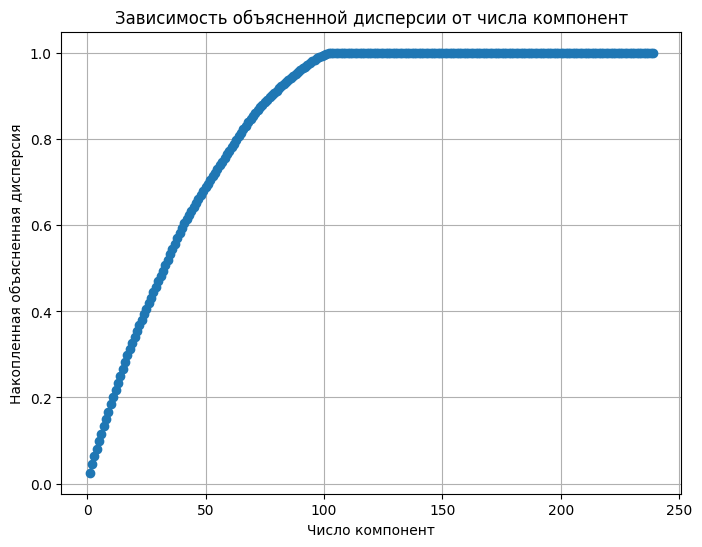

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

# Применим PCA без указания числа компонент, чтобы увидеть объясненную дисперсию для всех компонент
pca = PCA()
pca.fit(scaled_data)

# Визуализация доли объясненной дисперсии в зависимости от числа компонент
plt.figure(figsize=(8,6))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Зависимость объясненной дисперсии от числа компонент')
plt.xlabel('Число компонент')
plt.ylabel('Накопленная объясненная дисперсия')
plt.grid(True)
plt.show()

In [107]:
optimal_components = 100


pca = PCA(n_components=optimal_components)
reduced_data = pca.fit_transform(scaled_data)

df_reduced = pd.DataFrame(reduced_data, columns=[f'PC{i+1}' for i in range(optimal_components)])

df_reduced.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC91,PC92,PC93,PC94,PC95,PC96,PC97,PC98,PC99,PC100
0,0.751515,-3.695306,0.323737,-0.947350,-5.985246,-2.823929,-4.909997,-3.788480,3.529911,2.066266,...,-0.068725,0.002023,-0.269072,0.048867,-0.096501,0.163053,-0.331730,0.032383,-0.910941,-1.057136
1,-4.135682,-3.932178,-0.589748,-0.942165,-5.886165,-2.937556,-4.795036,-4.100655,3.886195,1.762593,...,-0.098497,-0.575659,0.314259,0.908963,0.781653,-1.421939,4.198712,0.139187,-0.073304,0.314066
2,-4.423261,-1.308555,0.764857,-1.004285,-3.355042,0.636882,8.051567,7.240219,0.755903,3.235400,...,-0.710159,-0.462109,-0.023882,0.352151,0.390769,-0.025221,0.170863,-0.074863,0.001197,-0.270164
3,-3.942758,-0.743613,0.745188,-0.751811,-2.843214,0.838215,8.226442,7.177652,0.893993,3.350418,...,-0.622925,0.091902,0.388804,-0.123380,0.179509,0.175995,0.955906,-0.124351,0.037355,0.039426
4,1.406357,-2.865034,-0.256684,-1.526266,-3.242829,0.754190,2.597775,5.382785,-8.778723,12.067440,...,0.801727,-1.251422,-1.143640,-0.766458,0.713856,-0.459570,0.356258,-0.052764,-0.015664,-0.658495


In [108]:
import numpy as np
import random
import pandas as pd

# Получаем индексы каждого класса
class_0_indices = np.where(y_bin == 0)[0]
class_1_indices = np.where(y_bin == 1)[0]

# Преобразуем индексы в списки и перемешиваем их
indices_0 = list(class_0_indices)
random.shuffle(indices_0)

indices_1 = list(class_1_indices)
random.shuffle(indices_1)

min_class = min(len(indices_0), len(indices_1))

# Определяем размеры выборок
test_size = int(min_class * 0.2 // 2)  # Размер тестовой выборки для каждого класса

indices_0 = np.array(indices_0, dtype=int)
indices_1 = np.array(indices_1, dtype=int)

# Тестовый набор (балансируем)
X_test = pd.concat([
    df_reduced.iloc[indices_0[:test_size]],
    df_reduced.iloc[indices_1[:test_size]]
])
y_test = np.concatenate([
    y_bin[indices_0[:test_size]],
    y_bin[indices_1[:test_size]]
])

# Тренировочный набор — всё, что осталось
train_indices = np.concatenate([
    indices_0[test_size:],
    indices_1[test_size:]
])

X_train = df_reduced.iloc[train_indices]
y_train = y_bin[train_indices]

# Проверим размеры выборок
print(f"Размер тренировочной выборки: {X_train.shape}, Размер тестовой выборки: {X_test.shape}")


Размер тренировочной выборки: (9659, 100), Размер тестовой выборки: (264, 100)


### Строим бейзлайны

In [109]:
# Random baseline

from sklearn.metrics import accuracy_score, classification_report

y_pred_random = np.random.choice([0, 1], size=len(y_test))
accuracy_random = accuracy_score(y_test, y_pred_random)
print(f'Точность рандомного классификатора: {accuracy_random * 100:.2f}%')

print(classification_report(y_test, y_pred_random))

Точность рандомного классификатора: 50.76%
              precision    recall  f1-score   support

         0.0       0.51      0.48      0.49       132
         1.0       0.51      0.54      0.52       132

    accuracy                           0.51       264
   macro avg       0.51      0.51      0.51       264
weighted avg       0.51      0.51      0.51       264



### Добавляем дерево решений

In [110]:
from sklearn.tree import DecisionTreeClassifier


clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.51      0.97      0.67       132
         1.0       0.73      0.08      0.15       132

    accuracy                           0.53       264
   macro avg       0.62      0.53      0.41       264
weighted avg       0.62      0.53      0.41       264



### Добавляем балансировку

In [111]:
clf_weighted = DecisionTreeClassifier(random_state=42, class_weight='balanced')
clf_weighted.fit(X_train, y_train)

# Оценка на тестовых данных
y_pred = clf_weighted.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.55      0.69      0.61       132
         1.0       0.59      0.45      0.51       132

    accuracy                           0.57       264
   macro avg       0.57      0.57      0.56       264
weighted avg       0.57      0.57      0.56       264



### Посмотрим какие признаки являются важными

#### Permutation importance


 **Как работает**

Permutation importance оценивает вклад признаков в качество модели, перемешивая значения каждого признака в валидационном наборе.
Если после перемешивания метрика (например, accuracy или MSE) сильно падает, значит признак важен; если почти не меняется — признак незначим.



**Разница с feature_importances_**

* feature_importances_ (у деревьев) основан на вкладe признака в уменьшение impurity при построении дерева.
* permutation_importance измеряет реальное влияние признака на качество предсказаний после обучения.
**Поэтому permutation importance не зависит от внутренней структуры модели и учитывает корреляции между признаками.**



 **Как и почему помогает улучшить модель**

Сам метод модель не улучшает, но его результаты позволяют:

* удалить шумовые и слабоинформативные признаки → меньше переобучения;
* выявить утечки или дублирующие признаки → выше обобщающая способность;
* сосредоточить модель на действительно значимых признаках → рост метрики на тесте.

В итоге отбор признаков на основе permutation importance делает модель проще, устойчивее и точнее.


In [ ]:
from sklearn.inspection import permutation_importance
import numpy as np

In [113]:
result = permutation_importance(clf_weighted, X_test, y_test, n_repeats=10, random_state=42)
perm_sorted_idx = result.importances_mean.argsort()
for i in perm_sorted_idx[::-1]:
    print(f"Признак {i}, важность: {result.importances_mean[i]:.4f}")

Признак 45, важность: 0.0254
Признак 37, важность: 0.0140
Признак 96, важность: 0.0133
Признак 88, важность: 0.0133
Признак 33, важность: 0.0129
Признак 12, важность: 0.0114
Признак 73, важность: 0.0110
Признак 24, важность: 0.0106
Признак 3, важность: 0.0102
Признак 70, важность: 0.0095
Признак 69, важность: 0.0080
Признак 53, важность: 0.0068
Признак 54, важность: 0.0068
Признак 91, важность: 0.0068
Признак 94, важность: 0.0061
Признак 7, важность: 0.0061
Признак 72, важность: 0.0057
Признак 36, важность: 0.0057
Признак 31, важность: 0.0053
Признак 79, важность: 0.0053
Признак 41, важность: 0.0049
Признак 77, важность: 0.0049
Признак 2, важность: 0.0045
Признак 67, важность: 0.0042
Признак 90, важность: 0.0042
Признак 19, важность: 0.0038
Признак 11, важность: 0.0038
Признак 34, важность: 0.0038
Признак 78, важность: 0.0034
Признак 6, важность: 0.0034
Признак 22, важность: 0.0030
Признак 61, важность: 0.0030
Признак 87, важность: 0.0023
Признак 15, важность: 0.0023
Признак 82, важнос

In [114]:
mean_importance = 0 #np.mean(result.importances_mean)
best_features_idx = np.where(result.importances_mean > mean_importance)[0]


X_train_best = X_train.values[:, best_features_idx]
X_test_best = X_test.values[:, best_features_idx]

clf_weighted = DecisionTreeClassifier(random_state=42, class_weight='balanced')
clf_weighted.fit(X_train_best, y_train)

# Оценка на тестовых данных
y_pred = clf_weighted.predict(X_test_best)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.56      0.67      0.61       132
         1.0       0.59      0.46      0.52       132

    accuracy                           0.57       264
   macro avg       0.57      0.57      0.56       264
weighted avg       0.57      0.57      0.56       264



### Попробуем подобрать гиперпараметры

Optuna — автоматическая оптимизация гиперпараметров

Суть:
Optuna — это библиотека для автоматического подбора гиперпараметров с использованием байесовской оптимизации.
Она обучается на прошлых запусках модели и постепенно приближает оптимальные значения параметров.

Как работает:

1. Определяется целевая функция (objective), которая возвращает метрику качества модели.
2. Optuna выполняет несколько проб (trials), предлагая разные комбинации параметров.
3. На основе уже полученных результатов она строит вероятностные модели (KDE):

   * l(θ) — распределение хороших гиперпараметров;
   * g(θ) — распределение плохих гиперпараметров.
4. Новые параметры выбираются так, чтобы максимизировать отношение l(θ)/g(θ), то есть быть похожими на хорошие и отличаться от плохих.

Преимущества:

* Не требует производных и работает с любой целевой функцией ("чёрный ящик").
* Эффективно сочетает исследование и использование найденных успешных областей.
* Поддерживает как непрерывные, так и категориальные параметры.


In [ ]:
import optuna
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

def objective(trial):
    max_depth = trial.suggest_int('max_depth', 2, 32)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    
    clf = DecisionTreeClassifier(
        max_depth=max_depth, 
        min_samples_split=min_samples_split, 
        min_samples_leaf=min_samples_leaf, 
        class_weight='balanced',
        random_state=42
    )

    score = cross_val_score(clf, X_train_best, y_train, cv=5)
    return np.mean(score)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print(f"Лучшие параметры: {study.best_params}")
print(f"Лучшая acc: {study.best_value:.3f}")


[I 2025-10-13 11:36:15,381] A new study created in memory with name: no-name-c933ead8-6960-4f25-9eb3-f63649949c47
[I 2025-10-13 11:36:18,369] Trial 0 finished with value: 0.5233465534008167 and parameters: {'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.5233465534008167.
[I 2025-10-13 11:36:21,938] Trial 1 finished with value: 0.6014074600637094 and parameters: {'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.6014074600637094.
[I 2025-10-13 11:36:24,555] Trial 2 finished with value: 0.4898058590738662 and parameters: {'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 6}. Best is trial 1 with value: 0.6014074600637094.
[I 2025-10-13 11:36:25,366] Trial 3 finished with value: 0.39589979553391164 and parameters: {'max_depth': 2, 'min_samples_split': 2, 'min_samples_leaf': 7}. Best is trial 1 with value: 0.6014074600637094.
[I 2025-10-13 11:36:29,291] Trial 4 finished with value: 0.6219

Лучшие параметры: {'max_depth': 28, 'min_samples_split': 6, 'min_samples_leaf': 1}
Лучшая средняя F1: 0.666


In [67]:
clf_weighted = DecisionTreeClassifier(random_state=42, max_depth = 28, min_samples_split=6, min_samples_leaf=1, class_weight='balanced')
clf_weighted.fit(X_train_best, y_train)

# Оценка на тестовых данных
y_pred = clf_weighted.predict(X_test_best)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.54      0.67      0.60       132
         1.0       0.56      0.43      0.49       132

    accuracy                           0.55       264
   macro avg       0.55      0.55      0.54       264
weighted avg       0.55      0.55      0.54       264



In [ ]:
import optuna
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score


def objective(trial):
    max_depth = trial.suggest_int('max_depth', 2, 32)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    
    clf = DecisionTreeClassifier(
        max_depth=max_depth, 
        min_samples_split=min_samples_split, 
        min_samples_leaf=min_samples_leaf, 
        class_weight='balanced',
        random_state=42
    )
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    score = cross_val_score(
        clf,
        X_train_best,
        y_train,
        cv=cv,
        n_jobs=-1
    )
    
    return np.mean(score)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print(f"Лучшие параметры: {study.best_params}")
print(f"Лучшая средняя acc: {study.best_value:.3f}")


[I 2025-10-13 11:38:29,886] A new study created in memory with name: no-name-fba8a279-98d0-4494-b8dc-9e9e8e415aa5
[I 2025-10-13 11:38:34,867] Trial 0 finished with value: 0.6239765705665331 and parameters: {'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.6239765705665331.
[I 2025-10-13 11:38:37,492] Trial 1 finished with value: 0.47406314967839747 and parameters: {'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.6239765705665331.
[I 2025-10-13 11:38:40,493] Trial 2 finished with value: 0.5719032286771462 and parameters: {'max_depth': 14, 'min_samples_split': 3, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.6239765705665331.
[I 2025-10-13 11:38:41,798] Trial 3 finished with value: 0.661766288935136 and parameters: {'max_depth': 29, 'min_samples_split': 10, 'min_samples_leaf': 1}. Best is trial 3 with value: 0.661766288935136.
[I 2025-10-13 11:38:42,868] Trial 4 finished with value: 0.6013

Лучшие параметры: {'max_depth': 29, 'min_samples_split': 7, 'min_samples_leaf': 1}
Лучшая средняя F1: 0.663


In [69]:
clf_weighted = DecisionTreeClassifier(random_state=42, max_depth = 29, min_samples_split=7, min_samples_leaf=1, class_weight='balanced')
clf_weighted.fit(X_train_best, y_train)

# Оценка на тестовых данных
y_pred = clf_weighted.predict(X_test_best)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.54      0.65      0.59       132
         1.0       0.56      0.44      0.49       132

    accuracy                           0.55       264
   macro avg       0.55      0.55      0.54       264
weighted avg       0.55      0.55      0.54       264



In [70]:
import optuna
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, balanced_accuracy_score

def objective(trial):
    max_depth = trial.suggest_int('max_depth', 2, 32)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    
    clf = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        class_weight='balanced',
        random_state=42
    )
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    score = cross_val_score(
        clf,
        X_train_best,
        y_train,
        cv=cv,
        scoring=make_scorer(balanced_accuracy_score),
        n_jobs=-1
    )
    
    return np.mean(score)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Лучшие параметры: {study.best_params}")
print(f"Лучшая средняя взвешенная accuracy: {study.best_value:.3f}")


[I 2025-10-13 11:42:39,756] A new study created in memory with name: no-name-092dbca9-653f-4fc1-b60d-e9e7a02d14bb
[I 2025-10-13 11:42:41,077] Trial 0 finished with value: 0.570792261765084 and parameters: {'max_depth': 25, 'min_samples_split': 3, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.570792261765084.
[I 2025-10-13 11:42:42,069] Trial 1 finished with value: 0.5764928305424212 and parameters: {'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 6}. Best is trial 1 with value: 0.5764928305424212.
[I 2025-10-13 11:42:42,997] Trial 2 finished with value: 0.5770277784543945 and parameters: {'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1}. Best is trial 2 with value: 0.5770277784543945.
[I 2025-10-13 11:42:44,253] Trial 3 finished with value: 0.5634615496054416 and parameters: {'max_depth': 30, 'min_samples_split': 6, 'min_samples_leaf': 3}. Best is trial 2 with value: 0.5770277784543945.
[I 2025-10-13 11:42:45,670] Trial 4 finished with value: 0.56920

Лучшие параметры: {'max_depth': 4, 'min_samples_split': 6, 'min_samples_leaf': 7}
Лучшая средняя взвешенная accuracy: 0.587


In [71]:
clf_weighted = DecisionTreeClassifier(random_state=42, max_depth = 4, min_samples_split=6, min_samples_leaf=7, class_weight='balanced')
clf_weighted.fit(X_train_best, y_train)

# Оценка на тестовых данных
y_pred = clf_weighted.predict(X_test_best)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.64      0.48      0.55       132
         1.0       0.59      0.73      0.65       132

    accuracy                           0.61       264
   macro avg       0.61      0.61      0.60       264
weighted avg       0.61      0.61      0.60       264



### Add SHAP-value

In [72]:
!python3 -m pip install shap


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 556 kB 424 kB/s eta 0:00:01
  Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
     |████████████████████████████████| 2.6 MB 675 kB/s eta 0:00:01
     |████████████████████████████████| 31.1 MB 9.7 MB/s eta 0:00:01    |██████▊                         | 6.5 MB 783 kB/s eta 0:00:32     |████████████████████████████████| 31.0 MB 9.7 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [87]:
import numpy as np
import random
import pandas as pd


class_0_indices = np.where(y_bin == 0)[0]
class_1_indices = np.where(y_bin == 1)[0]


indices_0 = list(class_0_indices)
random.shuffle(indices_0)

indices_1 = list(class_1_indices)
random.shuffle(indices_1)

min_class = min(len(indices_0), len(indices_1))


test_size = int(min_class * 0.2 // 2)  # Размер тестовой выборки для каждого класса

indices_0 = np.array(indices_0, dtype=int)
indices_1 = np.array(indices_1, dtype=int)


X_test = pd.concat([
    X.iloc[indices_0[:test_size]],
    X.iloc[indices_1[:test_size]]
])
y_test = np.concatenate([
    y_bin[indices_0[:test_size]],
    y_bin[indices_1[:test_size]]
])


train_indices = np.concatenate([
    indices_0[test_size:],
    indices_1[test_size:]
])

X_train = X.iloc[train_indices]
y_train = y_bin[train_indices]


print(f"Размер тренировочной выборки: {X_train.shape}, Размер тестовой выборки: {X_test.shape}")


Размер тренировочной выборки: (9659, 239), Размер тестовой выборки: (264, 239)


In [89]:
mean_importance = 0 #np.mean(result.importances_mean)
best_features_idx = np.where(result.importances_mean > mean_importance)[0]


X_train_best = X_train.iloc[:, best_features_idx]
X_test_best = X_test.iloc[:, best_features_idx]

clf_weighted = DecisionTreeClassifier(random_state=42, class_weight='balanced')
clf_weighted.fit(X_train_best, y_train)

# Оценка на тестовых данных
y_pred = clf_weighted.predict(X_test_best)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.56      0.64      0.60       132
         1.0       0.58      0.51      0.54       132

    accuracy                           0.57       264
   macro avg       0.57      0.57      0.57       264
weighted avg       0.57      0.57      0.57       264



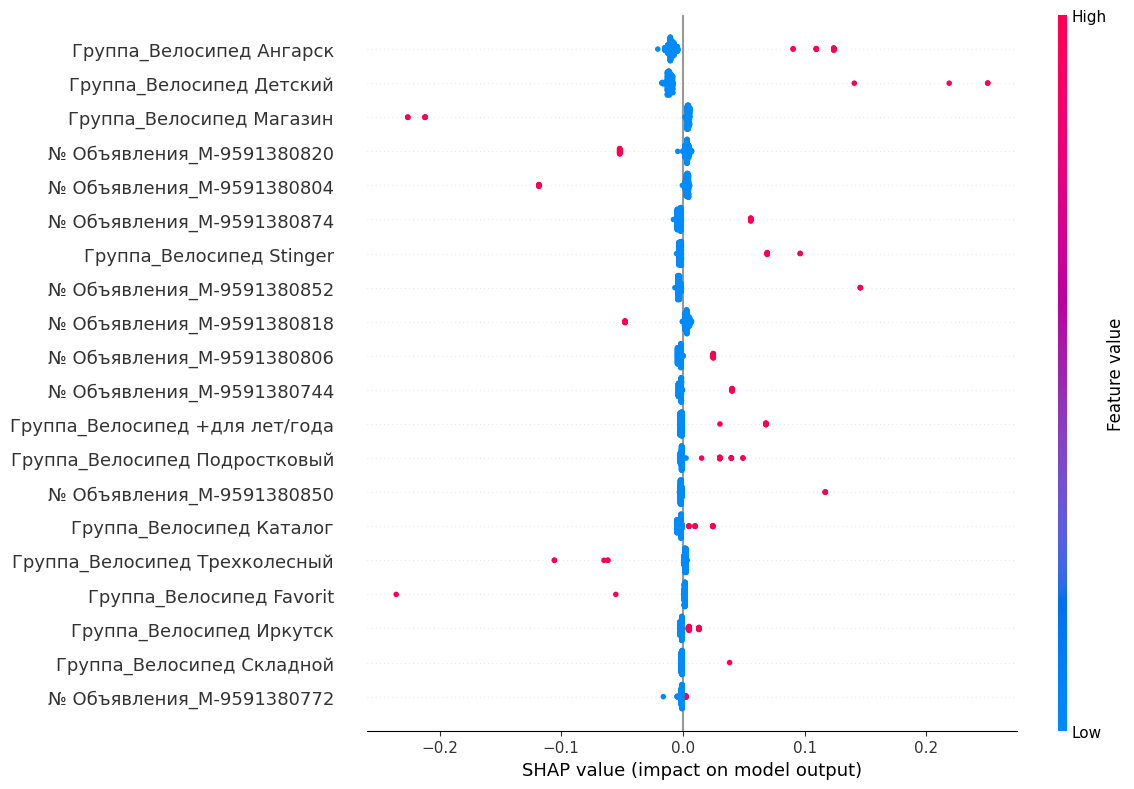

In [90]:
import shap


explainer = shap.Explainer(clf_weighted)
shap_values = explainer(X_test_best.values)
shap.summary_plot(shap_values.values[:,:,1], X_test_best.values,  feature_names=X_test_best.columns, plot_size=(12, 8))